In [1]:
# --- Imports ---
import numpy as np
from scipy import linalg

import numpy as np
from dataclasses import dataclass
import matplotlib.pyplot as plt


@dataclass
class MotorParams:
    R: float
    L: float
    Ke: float
    Kt: float
    Vmax: float

@dataclass
class MacroActuatorParams:
    M: np.ndarray
    K: np.ndarray
    C: np.ndarray
    def __post_init__(self):
        for name, arr in [("M", self.M), ("K", self.K), ("C", self.C)]:
            if arr.shape != (2,2):
                raise ValueError(f"{name} must have shape (2,2), got {arr.shape}")

@dataclass
class MicroActuatorParams:
    M: np.ndarray
    B: np.ndarray
    def __post_init__(self):
        for name, arr in [("M", self.M), ("B", self.B)]:
            if arr.shape != (2,2):
                raise ValueError(f"{name} must have shape (2,2), got {arr.shape}")
            
            



In [2]:
def load_macro_from_npz(npz_path, axes=(0, 1)):
    """
    Load operational-space (xyz) linearized matrices saved from Pinocchio projection
    and extract a 2D subspace (default: x,y).

    axes: tuple of two indices to select from {0:x, 1:y, 2:z}
    Returns: M2, C2, K2 plus some extras (q0, Jpos_flex, etc.)
    """
    data = np.load(npz_path, allow_pickle=False)

    # These names match what you saved in the other script
    Lambda = data["Lambda_xyz"]  # (3,3)
    Dx     = data["Dx_xyz"]      # (3,3)
    Kx     = data["Kx_xyz"]      # (3,3)

    a0, a1 = axes

    M2 = Lambda[np.ix_([a0, a1], [a0, a1])]
    C2 = Dx[np.ix_([a0, a1], [a0, a1])]
    K2 = Kx[np.ix_([a0, a1], [a0, a1])]

    extras = {k: data[k] for k in data.files if k not in ["Lambda_xyz", "Dx_xyz", "Kx_xyz"]}
    return M2, C2, K2, extras



M2, C2, K2, extras = load_macro_from_npz("./data/linearized_operational_space_xyz.npz", axes=(0, 1))  # (x,y)

# Optional: symmetrize numerically if you want (not required, but sometimes helps)
# M2 = 0.5 * (M2 + M2.T)
# K2 = 0.5 * (K2 + K2.T)
# C2 = 0.5 * (C2 + C2.T)

print("\nLoaded operational-space macro matrices (x,y):")
print("M_macro:\n", M2)
print("C_macro:\n", C2)
print("K_macro:\n", K2)

p_macro = MacroActuatorParams(M=M2, K=K2, C=C2)
p_m     = MotorParams(R=18.2, L=100e-3, Ke=89.0, Kt=157.0, Vmax=540.0/np.sqrt(2))
p_micro = MicroActuatorParams(M=np.eye(2)*80.0, B=np.eye(2)*1.0)


Loaded operational-space macro matrices (x,y):
M_macro:
 [[215.64254037 -21.55407231]
 [-21.55407231 147.49265873]]
C_macro:
 [[ 2.77263850e+03  1.01081932e-12]
 [-4.91643992e-13  1.13023795e+03]]
K_macro:
 [[ 4.29769889e+06 -1.49937401e-08]
 [-6.49949346e-10  4.60912641e+05]]


In [3]:
# --- Actuator bandwidth / lag ---
f_c = 500.0
wc  = 2*np.pi*f_c
tau = 1.0 / wc



# --- System matrices ---
M = np.asarray(M2, dtype=float)
C = np.asarray(C2, dtype=float)
K = np.asarray(K2, dtype=float)

M_micro = np.asarray(p_micro.M, dtype=float)
B = np.asarray(p_micro.B, dtype=float)   # viscous coupling matrix (2x2)

# --- Process stiffness (placeholder) ---
Kp = np.diag([1e5, 1e5])  # N/m (example)

# --- Build A, Bu for state: [x(2), xdot(2), p(2), pdot(2), F(2)] ---
I = np.eye(2)
Z = np.zeros((2,2))

Minv = np.linalg.inv(M)
Mmic_inv = np.linalg.inv(M_micro)

A = np.zeros((10, 10))
Bu = np.zeros((10, 2))

# xdot = xdot
A[0:2, 2:4] = I

# xddot = -M^-1 K x - M^-1 C xdot + M^-1 B (pdot - xdot) - M^-1 F
A[2:4, 0:2]   = -Minv @ K
A[2:4, 2:4]   = -Minv @ (C + B)
A[2:4, 6:8]   =  Minv @ B
A[2:4, 8:10]  = -Minv

# pdot = pdot
A[4:6, 6:8] = I

# pddot = +Mmic^-1 F - Mmic^-1 B (pdot - xdot) + Mmic^-1 Kp x + Mmic^-1 Kp p
A[6:8, 0:2]   =  Mmic_inv @ Kp          # <-- process force term into x
A[6:8, 2:4]   =  Mmic_inv @ B           # from -B(pdot-xdot): +B*xdot
A[6:8, 4:6]   =  Mmic_inv @ Kp          # <-- process force term into p
A[6:8, 6:8]   = -Mmic_inv @ B           # from -B(pdot-xdot): -B*pdot
A[6:8, 8:10]  =  Mmic_inv               # actuator force on micro

# Fdot = -(1/tau)F + (1/tau)u
A[8:10, 8:10] = -(1.0/tau) * I
Bu[8:10, 0:2] =  (1.0/tau) * I



In [4]:
# --- Open-loop poles ---
eig_ol = np.linalg.eigvals(A)
eig_ol_sorted = eig_ol[np.argsort(np.real(eig_ol))]

print("Open-loop poles (sorted by real part):")
for lam in eig_ol_sorted:
    print(f"{lam.real:+.6e} {lam.imag:+.6e}j")


Open-loop poles (sorted by real part):
-3.141593e+03 +0.000000e+00j
-3.141593e+03 +0.000000e+00j
-3.536145e+01 +0.000000e+00j
-3.536056e+01 +0.000000e+00j
-6.602641e+00 +1.422517e+02j
-6.602641e+00 -1.422517e+02j
-3.816643e+00 +5.569661e+01j
-3.816643e+00 -5.569661e+01j
+3.534922e+01 +0.000000e+00j
+3.535000e+01 +0.000000e+00j


In [5]:
# Controller Parameters
f_c = 500.0
wc = 2*np.pi*f_c
tau = 1.0 / wc

xmax   = 1e0     # m
xdmax  = 1e0      # m/s
pmax   = 1e-6    # m
pdmax  = 1e-2     # m/s
umax   = 1000.0     # N (force command)

# LQR weights
Q = np.zeros((10,10))
Q[0:2,0:2] = (1/xmax**2)*np.eye(2)   #x
Q[2:4,2:4] = (1/xdmax**2)*np.eye(2)  #xdot
Q[4:6,4:6] = (1/pmax**2)*np.eye(2)   #p
Q[6:8,6:8] = (1/pdmax**2)*np.eye(2)  #pdot
Q[8:10,8:10] = (1/umax**2)*np.eye(2) #if wanted F

R = (1/umax**2)*np.eye(2)
# R = np.diag([1.0, 1.0])

# Solve CARE and compute gain
P = linalg.solve_continuous_are(A, Bu, Q, R)
K_lqr = np.linalg.inv(R) @ (Bu.T @ P)

print("K_lqr shape:", K_lqr.shape)  # (2, 10)


K_lqr shape: (2, 10)


In [6]:
# --- Closed-loop poles (A - Bu*K) ---
A_cl = A - Bu @ K_lqr
eig_cl = np.linalg.eigvals(A_cl)
eig_cl_sorted = eig_cl[np.argsort(np.real(eig_cl))]

print("Closed-loop poles (sorted by real part):")
for lam in eig_cl_sorted:
    print(f"{lam.real:+.6e} {lam.imag:+.6e}j")

stable = np.all(np.real(eig_cl) < 0)
print("\nClosed-loop asymptotically stable:", stable)


Closed-loop poles (sorted by real part):
-4.709463e+03 +0.000000e+00j
-4.709457e+03 +0.000000e+00j
-1.886716e+03 +2.186050e+03j
-1.886716e+03 -2.186050e+03j
-1.886687e+03 +2.186077e+03j
-1.886687e+03 -2.186077e+03j
-6.595946e+00 +1.405405e+02j
-6.595946e+00 -1.405405e+02j
-3.816440e+00 +4.926870e+01j
-3.816440e+00 -4.926870e+01j

Closed-loop asymptotically stable: True


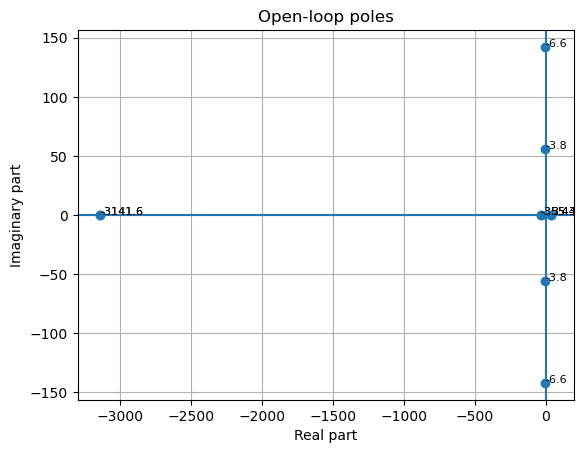

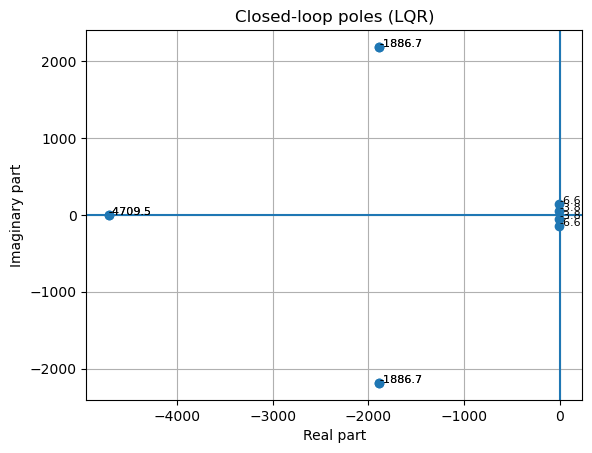

In [7]:

import matplotlib.pyplot as plt

def plot_poles(eigs, title):
    plt.figure()
    plt.axhline(0)
    plt.axvline(0)
    plt.scatter(np.real(eigs), np.imag(eigs))
    
    for lam in eigs:
        plt.text(lam.real, lam.imag, f"{lam.real:.1f}", fontsize=8)
    
    plt.xlabel("Real part")
    plt.ylabel("Imaginary part")
    plt.title(title)
    plt.grid(True)
    plt.show()


plot_poles(eig_ol, "Open-loop poles")
plot_poles(eig_cl, "Closed-loop poles (LQR)")


In [8]:
def compute_entry_exit_angles_downmilling(
    
    r_engagement : float,
    v : float,
    D : float
    
):
    
    # Current tool entry / exit angles: --> https://www.sciencedirect.com/science/article/pii/S0888327020307044#b0160
    # Downmilling setup
    R = D/2
    b =  r_engagement  # radial depth of cut 
    v =  0.0  # We assume full entry of the tool thus distance from the edge is zero. (No partial entry)
    arg = np.clip((R - b) / R , -1.0, 1.0) # np.clip(1.0 - 2.0*b/D, -1.0, 1.0)
    arg1 = np.clip(v / (D/2) ,0.0, 1.0)
    phi_st = np.pi / 2 + np.arcsin(arg)
    phi_ex = np.pi / 2 + np.arccos(arg1)
        
    return phi_st , phi_ex



def zero_order_dF(
    c: float,
    a_axial: float,
    b_radial: float,
    D: float,
    N_teeth: float,
    phi_st: float,
    phi_ex: float,
    n_hat: np.ndarray,
    Ktc: float,
    Krc: float
):
    nx, ny = n_hat
    tx, ty = -ny, nx
    v = 0.0  # full entry assumption

    dphi_st_db = -1.0 / np.sqrt(b_radial * (D - b_radial))
    dphi_ex_dv = -2.0 / np.sqrt(D**2 - 4*v**2)

    def q(phi):
        h = c * np.sin(phi)
        T = np.array([[-np.cos(phi), -np.sin(phi)],
                      [ np.sin(phi), -np.cos(phi)]])
        K = np.array([Ktc, Krc])
        return a_axial * (T @ K) * h

    dF_dv = N_teeth/(2*np.pi) * q(phi_ex) * dphi_ex_dv
    dF_db = N_teeth/(2*np.pi) * (-q(phi_st) * dphi_st_db)

    dF_dx = dF_db * (-nx) + dF_dv * (-tx)
    dF_dy = dF_db * (-ny) + dF_dv * (-ty)

    return np.column_stack((dF_dx, dF_dy))

def Rtheta(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s],
                     [s,  c]], dtype=float)

def rotate_jacobian(J_local, theta):
    R = Rtheta(theta)
    return R @ J_local @ R.T

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Sweep settings ---
thetas_deg = np.linspace(0, 360, 360 // 2 + 1)
thetas = np.deg2rad(thetas_deg)
a_values = np.linspace(0.0, 80.0)


max_real_ol = np.zeros((len(a_values), len(thetas)))
max_real_cl_sched = np.full((len(a_values), len(thetas)), np.nan)


# --- Base A ---
A_base = A.copy()

# --- Milling parameters ---
Ktc = 1930.4
Krc = 1159.6
b_radial = 5.0
D = 20.0
N_teeth = 8

feed = 10.0   # mm/s
rpm  = 400.0  # rpm

fz = feed / (N_teeth * (rpm/60.0))  # mm/tooth

n_hat = np.array([0.0, 1.0])  # top edge in +y direction
phi_st, phi_ex = compute_entry_exit_angles_downmilling(r_engagement=b_radial, v=0.0, D=D)


xmax   = 1e0     # m
xdmax  = 1e0      # m/s
pmax   = 1e-6    # m
pdmax  = 1e-2     # m/s
umax   = 1000.0     # N (force command)

# LQR weights
Q = np.zeros((10,10))
Q[0:2,0:2] = (1/xmax**2)*np.eye(2)   #x
Q[2:4,2:4] = (1/xdmax**2)*np.eye(2)  #xdot
Q[4:6,4:6] = (1/pmax**2)*np.eye(2)   #p
Q[6:8,6:8] = (1/pdmax**2)*np.eye(2)  #pdot
# Q[8:10,8:10] = (1/umax**2)*np.eye(2) #if wanted F

R = (1/umax**2)*np.eye(2)

# --- Sweep ---
for i, a in enumerate(a_values):
    for j, th in enumerate(thetas):

        J_local = zero_order_dF(c=fz, a_axial=a, b_radial=b_radial, D=D,
                                N_teeth=N_teeth, phi_st=phi_st, phi_ex=phi_ex,
                                n_hat=n_hat, Ktc=Ktc, Krc=Krc)  # N/mm

        Kp = rotate_jacobian(J_local * 1e3, theta=th)  # N/m

        A_tmp = A_base.copy()
        A_tmp[6:8, 0:2] = Mmic_inv @ Kp
        A_tmp[6:8, 4:6] = Mmic_inv @ Kp

        max_real_ol[i, j] = np.max(np.real(np.linalg.eigvals(A_tmp)))

        try:
            P = linalg.solve_continuous_are(A_tmp, Bu, Q, R)
            K_lqr_tmp = np.linalg.solve(R, Bu.T @ P) 
            
            # Closed-loop metric
            A_cl = A_tmp - Bu @ K_lqr_tmp
            max_real_cl_sched[i, j] = np.max(np.real(np.linalg.eigvals(A_cl)))
            min_eig = np.min(np.real(np.linalg.eigvals(A_cl)))
            
            # print(f"Closed-loop  real parts: {np.real(np.linalg.eigvals(A_cl))}")
            

        except Exception:
            print("failed at a =", a, "th =", np.rad2deg(th))
            pass

print("Sweep done.")


Closed-loop  real parts: [-6.60007941e+00 -6.60007941e+00 -3.81230245e+00 -3.81230245e+00
 -3.92218502e+03 -3.92218365e+03 -1.90463743e+03 -1.90463743e+03
 -1.90463859e+03 -1.90463859e+03]
Closed-loop  real parts: [-6.60007941e+00 -6.60007941e+00 -3.81230245e+00 -3.81230245e+00
 -3.92218502e+03 -3.92218365e+03 -1.90463743e+03 -1.90463743e+03
 -1.90463859e+03 -1.90463859e+03]
Closed-loop  real parts: [-6.60007941e+00 -6.60007941e+00 -3.81230245e+00 -3.81230245e+00
 -3.92218502e+03 -3.92218365e+03 -1.90463743e+03 -1.90463743e+03
 -1.90463859e+03 -1.90463859e+03]
Closed-loop  real parts: [-6.60007941e+00 -6.60007941e+00 -3.81230245e+00 -3.81230245e+00
 -3.92218502e+03 -3.92218365e+03 -1.90463743e+03 -1.90463743e+03
 -1.90463859e+03 -1.90463859e+03]
Closed-loop  real parts: [-6.60007941e+00 -6.60007941e+00 -3.81230245e+00 -3.81230245e+00
 -3.92218502e+03 -3.92218365e+03 -1.90463743e+03 -1.90463743e+03
 -1.90463859e+03 -1.90463859e+03]
Closed-loop  real parts: [-6.60007941e+00 -6.60007941e+

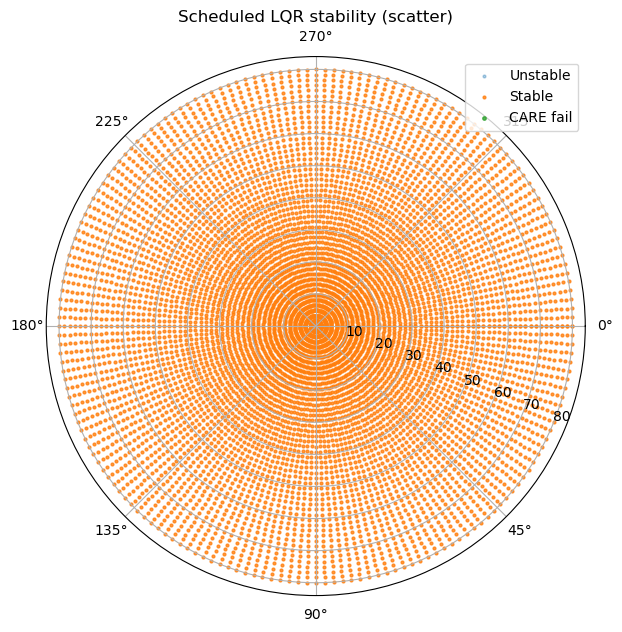

In [21]:
Theta, Rr = np.meshgrid(thetas, a_values)

stable = (max_real_cl_sched < 0) & (~np.isnan(max_real_cl_sched))
unstable = (max_real_cl_sched >= 0) & (~np.isnan(max_real_cl_sched))
failed = np.isnan(max_real_cl_sched)

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(7,7))
ax.scatter(Theta[unstable], Rr[unstable], s=4, alpha=0.35, label="Unstable")
ax.scatter(Theta[stable],   Rr[stable],   s=4, alpha=0.8,  label="Stable")
ax.scatter(Theta[failed],   Rr[failed],   s=6, alpha=0.8,  label="CARE fail")

ax.set_title("Scheduled LQR stability (scatter)")
ax.set_theta_zero_location("E")
ax.set_theta_direction(-1)
ax.legend(loc="upper right")
plt.show()


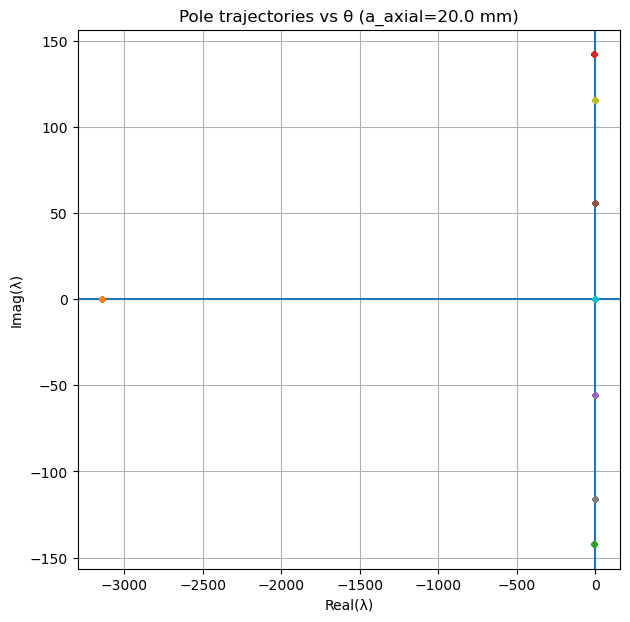

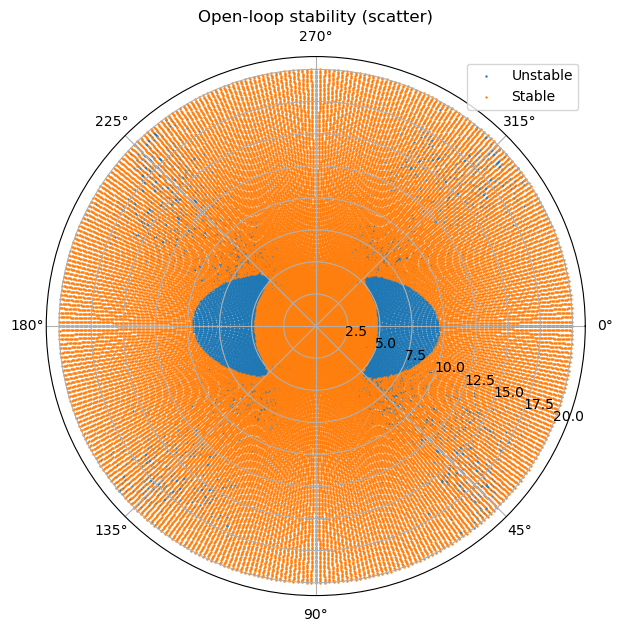

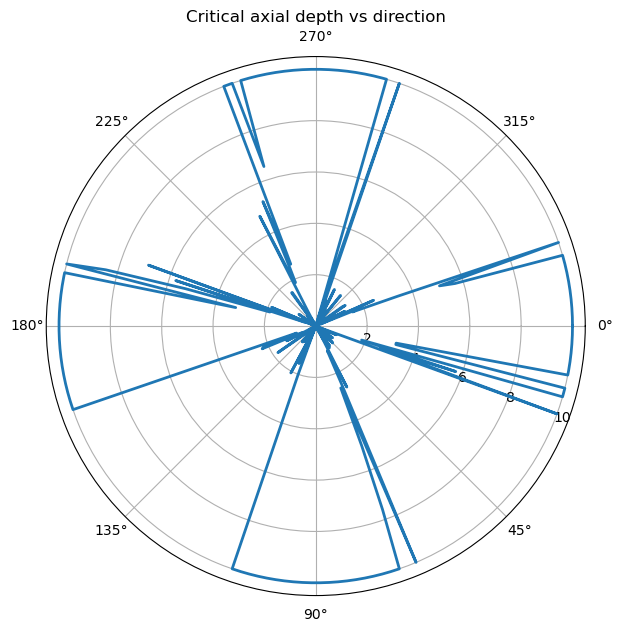